# Cointegration

In [13]:
from statsmodels.tsa.stattools import coint
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
filtered_residuals = pd.read_csv("../data/manipulated/pr_filtered_residuals.csv", index_col=0, parse_dates=True)
train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)

train_start = train_residuals.index.min()
train_end = train_residuals.index.max()

filtered_train_residuals = filtered_residuals.loc[train_start:train_end]

assets = filtered_train_residuals.columns

In [15]:
def find_cointegrated_pairs(residuals_df, candidates, pvalue_threshold=0.05):
    pairs = []
    tickers = list(candidates)

    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            a, b = tickers[i], tickers[j]
            _, pvalue, _ = coint(residuals_df[a], residuals_df[b])
            if pvalue < pvalue_threshold:
                # estimate hedge ratio
                model = LinearRegression().fit(
                    residuals_df[[b]], residuals_df[a]
                )
                beta = model.coef_[0]
                pairs.append((a, b, pvalue, beta))

    pairs_df = pd.DataFrame(pairs, columns=["asset_a", "asset_b", "pvalue", "beta"])
    return pairs_df.sort_values("pvalue")

In [16]:
cointegrated_pairs = find_cointegrated_pairs(filtered_train_residuals, assets)

In [17]:
cointegrated_pairs.head()

,asset_a,asset_b,pvalue,beta
2,CDW,HAS,0.0,1.245548
43,CTSH,ACN,0.0,0.833156
42,CTSH,CSX,0.0,0.874627
45,CTSH,IT,0.0,0.969965
44,CTSH,MSI,0.0,0.976822


In [18]:
cointegrated_pairs.to_csv("../data/manipulated/cointegrated_pairs.csv", index=False)

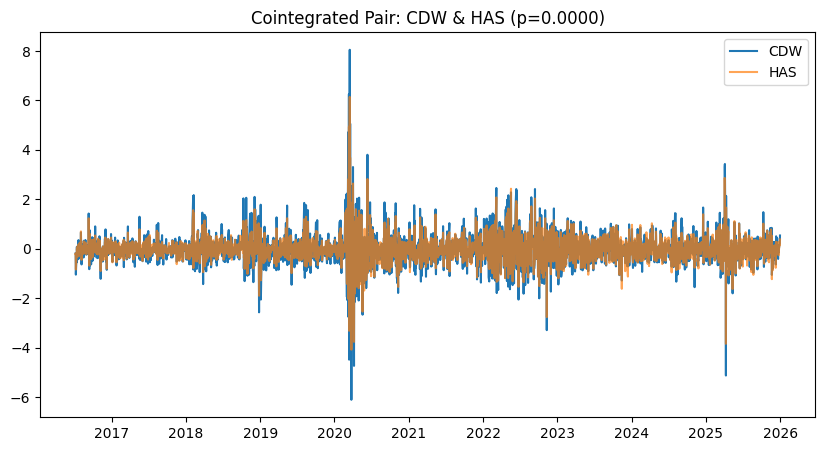

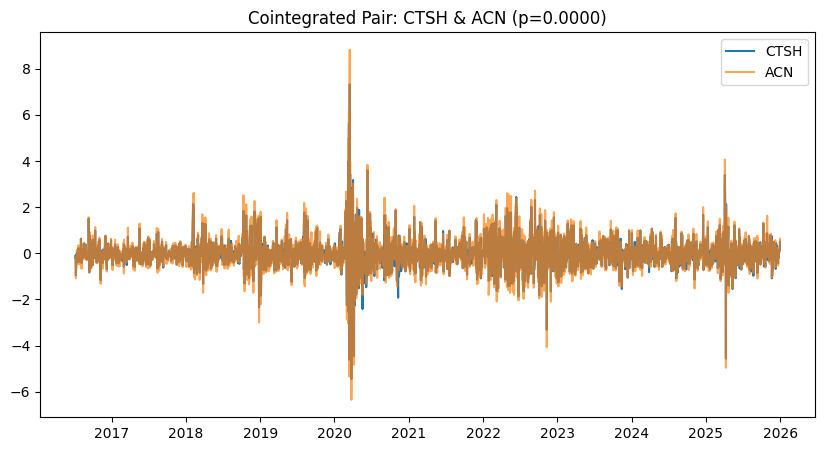

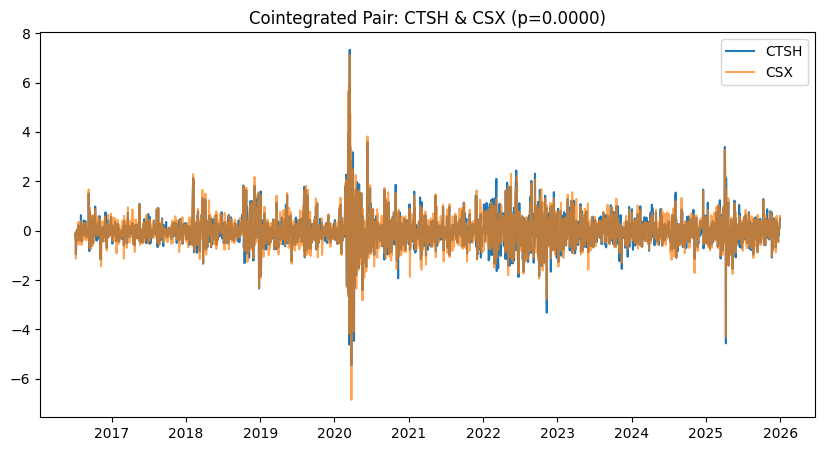

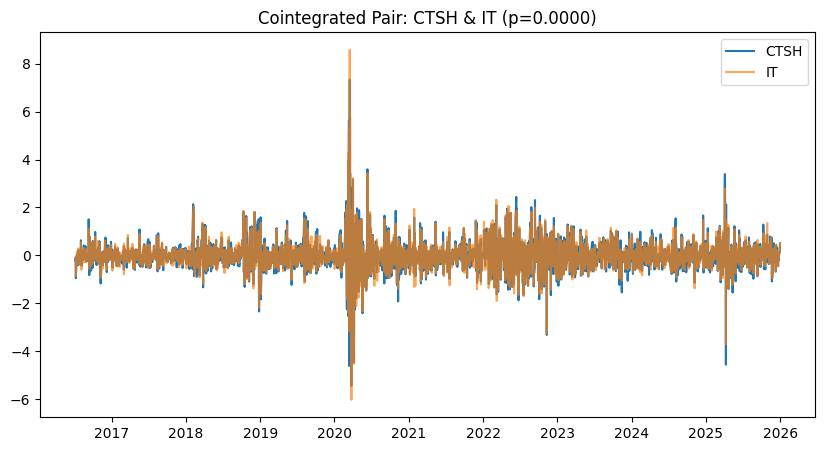

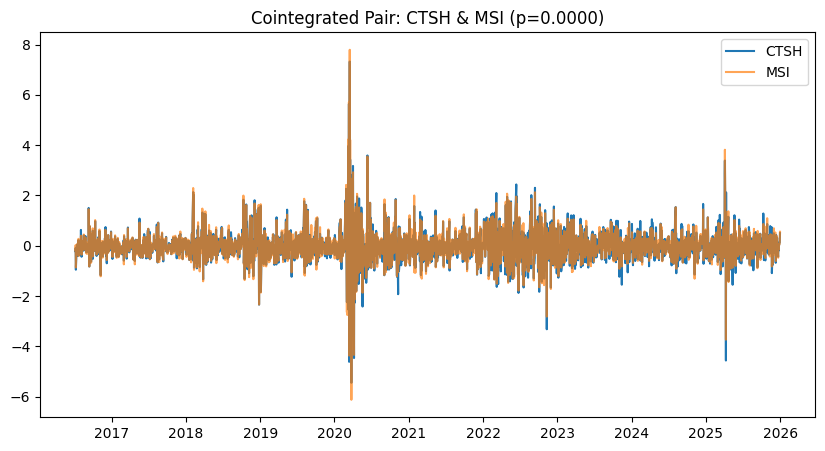

In [12]:
# make plot of top 5 most cointegrated pairs
top_pairs = cointegrated_pairs.head(5)
for _, row in top_pairs.iterrows():
    a, b = row["asset_a"], row["asset_b"]
    plt.figure(figsize=(10, 5))
    plt.plot(filtered_residuals[a], label=a)
    plt.plot(filtered_residuals[b], label=b, alpha=0.7)
    plt.title(f"Cointegrated Pair: {a} & {b} (p={row['pvalue']:.4f})")
    plt.legend()
    plt.show()